In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [4]:
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")

print("Isi train:")
print(os.listdir(train_path)[:10])

print("\nIsi val:")
print(os.listdir(val_path)[:10])

Isi train:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']

Isi val:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


In [5]:
train_classes = sorted(os.listdir(train_path))
val_classes = sorted(os.listdir(val_path))

print("Jumlah kelas train:", len(train_classes))
print("Jumlah kelas val:", len(val_classes))

print("\nKelas train:")
for i, class_name in enumerate(train_classes):
    print(i, class_name)

Jumlah kelas train: 38
Jumlah kelas val: 38

Kelas train:
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_mi

In [6]:
train_counts = {}

for class_name in train_classes:
    class_path = os.path.join(train_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    train_counts[class_name] = len(images)


val_counts = {}

for class_name in val_classes:
    class_path = os.path.join(val_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    val_counts[class_name] = len(images)

In [7]:
df_counts = pd.DataFrame({
    "class": train_classes,
    "train": [train_counts[class_name] for class_name in train_classes],
    "val": [val_counts[class_name] for class_name in train_classes]
})

df_counts["total"] = df_counts["train"] + df_counts["val"]

df_counts

,class,train,val,total
0,Apple___Apple_scab,504,126,630
1,Apple___Black_rot,496,125,621
2,Apple___Cedar_apple_rust,220,55,275
3,Apple___healthy,1316,329,1645
4,Blueberry___healthy,1202,300,1502
5,Cherry_(including_sour)___Powdery_mildew,842,210,1052
6,Cherry_(including_sour)___healthy,684,170,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410,103,513
8,Corn_(maize)___Common_rust_,953,239,1192
9,Corn_(maize)___Northern_Leaf_Blight,788,197,985


In [8]:
print("Total gambar train:", df_counts["train"].sum())
print("Total gambar val:", df_counts["val"].sum())
print("Total seluruh gambar:", df_counts["total"].sum())

Total gambar train: 43444
Total gambar val: 10861
Total seluruh gambar: 54305


In [9]:
print("Kelas dengan gambar train terbanyak:")
print(df_counts.loc[df_counts["train"].idxmax()])

print("\nKelas dengan gambar train paling sedikit:")
print(df_counts.loc[df_counts["train"].idxmin()])

Kelas dengan gambar train terbanyak:
class    Orange___Haunglongbing_(Citrus_greening)
train                                        4405
val                                          1102
total                                        5507
Name: 15, dtype: object

Kelas dengan gambar train paling sedikit:
class    Potato___healthy
train                 121
val                    31
total                 152
Name: 22, dtype: object


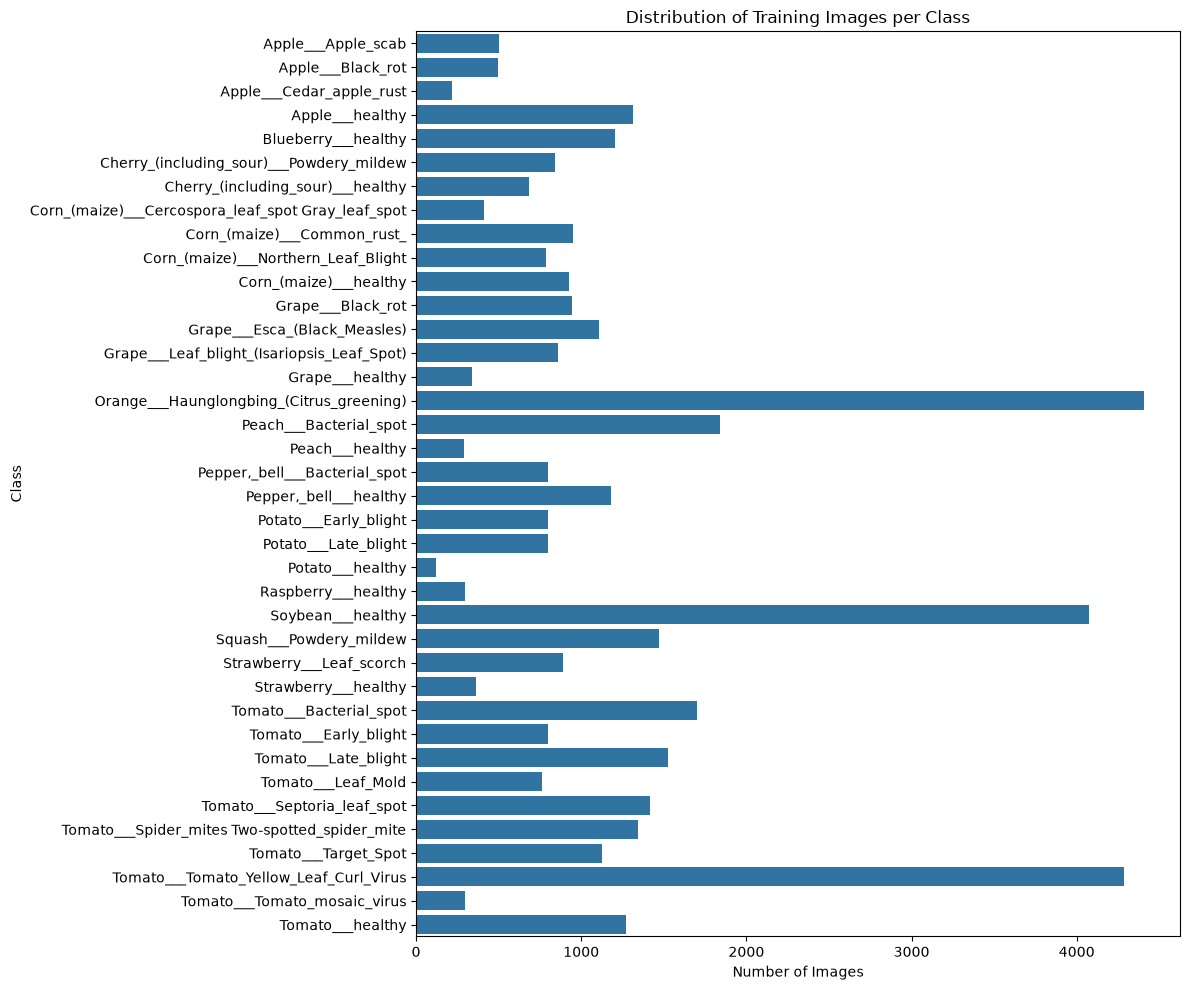

In [10]:
plt.figure(figsize=(12, 10))

sns.barplot(
    data=df_counts,
    x="train",
    y="class"
)

plt.title("Distribution of Training Images per Class")
plt.xlabel("Number of Images")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

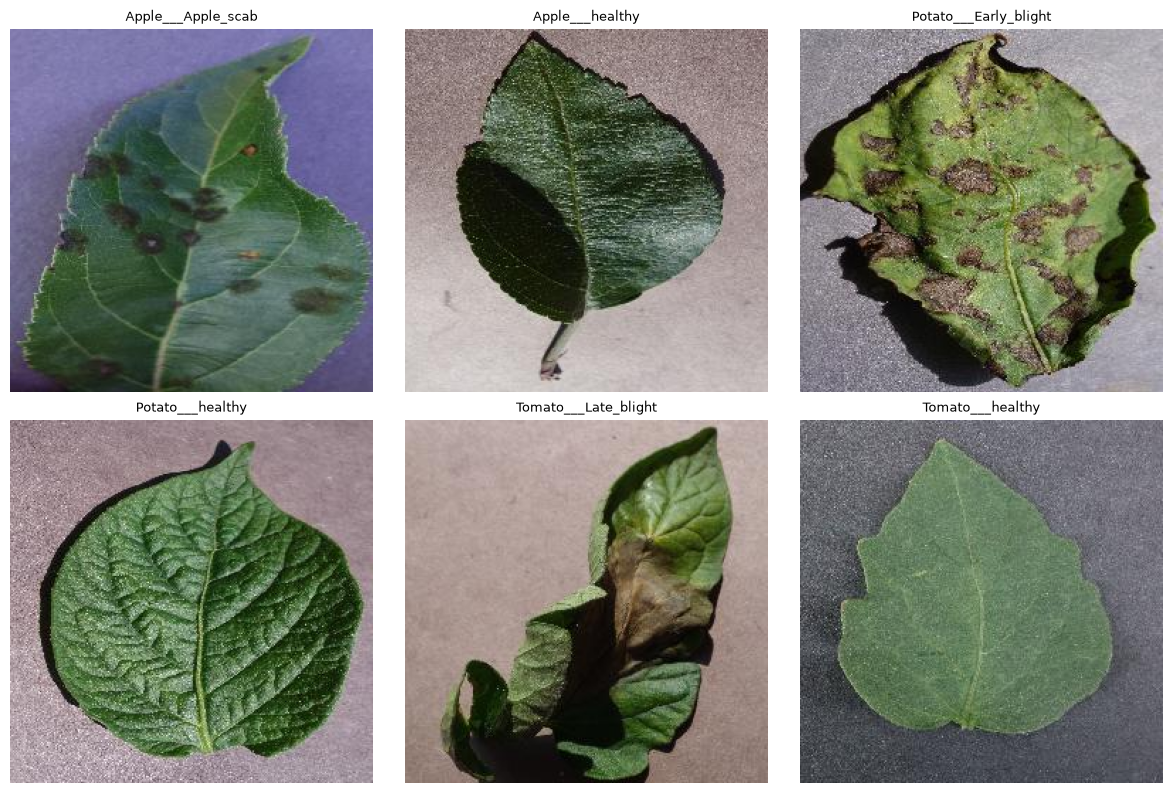

In [11]:
selected_classes = [
    "Apple___Apple_scab",
    "Apple___healthy",
    "Potato___Early_blight",
    "Potato___healthy",
    "Tomato___Late_blight",
    "Tomato___healthy"
]

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(train_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
sample_class = train_classes[0]
sample_path = os.path.join(train_path, sample_class)

sample_file = [
    file for file in os.listdir(sample_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
][0]

image = Image.open(os.path.join(sample_path, sample_file))

print("Ukuran gambar:", image.size)
print("Mode gambar:", image.mode)

Ukuran gambar: (256, 256)
Mode gambar: RGB


In [13]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [14]:
print("GPU:", tf.config.list_physical_devices("GPU"))

GPU: []


In [15]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 38

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: (224, 224)
Batch size: 32
Number of classes: 38


In [16]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.


In [17]:
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 3)
Label shape: (32,)


In [18]:
class_names = train_ds.class_names

print("Jumlah kelas:", len(class_names))

for i, class_name in enumerate(class_names):
    print(i, class_name)

Jumlah kelas: 38
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_mites Two-spotted_spider_mite
34 Tomato___T

In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

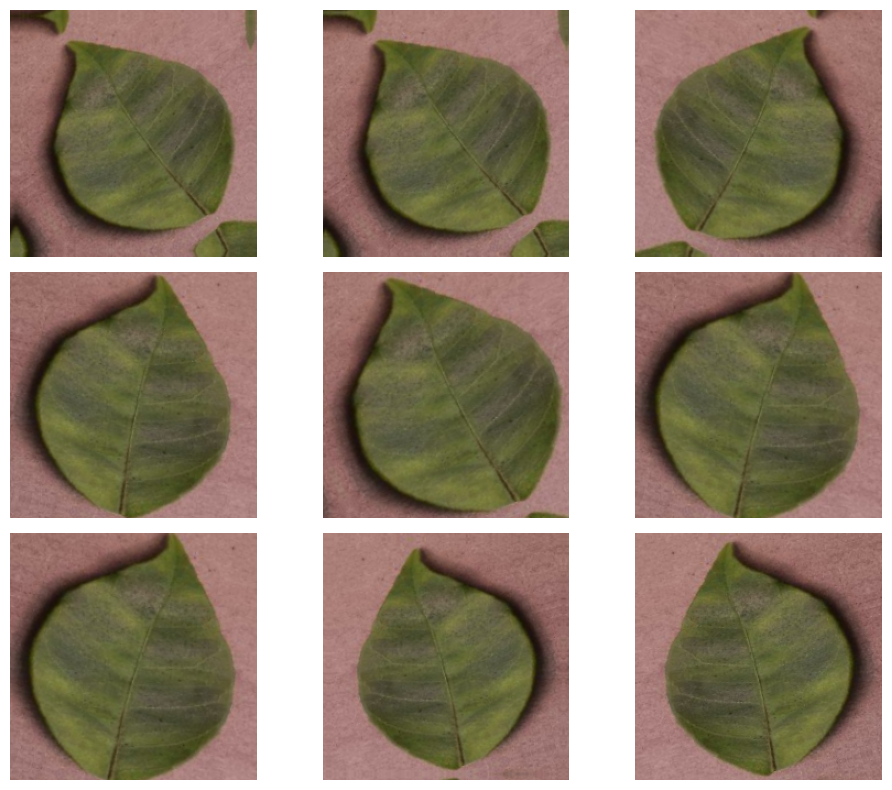

In [20]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    first_image = images[0]

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0),
            training=True
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(
            tf.cast(
                tf.clip_by_value(augmented_image[0], 0, 255),
                tf.uint8
            )
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [22]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [23]:
model = tf.keras.Sequential([
    data_augmentation,

    tf.keras.layers.Rescaling(1./127.5, offset=-1),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (1, 7, 7, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 1280)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 38)                │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)